In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Titanic-Dataset.csv") ## read dataset

In [3]:
df.head() ## view first 5 rows

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info() ## it looks like there are null values in the dataset; we will drop Cabin as it is mostly null, and impute for Age and Embarked

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.drop(columns=['Cabin'],inplace=True) ## removing Cabin

In [6]:
df['Embarked'] = df['Embarked'].fillna('S')

<Axes: xlabel='Age', ylabel='Count'>

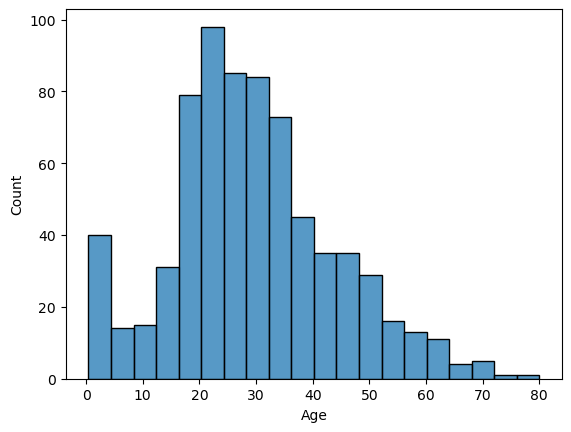

In [7]:
sns.histplot(df['Age']) ## age is right skewed, so we will use median

In [8]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [9]:
df.info() ## no more missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [10]:
df.drop(columns=['PassengerId', 'Name', 'Ticket'],inplace=True) ## removing unnecessary columns for our models

In [11]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked']) ## encoding categorical variables

In [12]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [13]:
df.describe().round(2) ## summary statistics

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
count,891.00,891.00,891.00,891.00,891.00,891.00,891.00,891.00
mean,0.38,2.31,0.65,29.36,0.52,0.38,32.20,1.54
std,0.49,0.84,0.48,13.02,1.10,0.81,49.69,0.79
min,0.00,1.00,0.00,0.42,0.00,0.00,0.00,0.00
25%,0.00,2.00,0.00,22.00,0.00,0.00,7.91,1.00
50%,0.00,3.00,1.00,28.00,0.00,0.00,14.45,2.00
75%,1.00,3.00,1.00,35.00,1.00,0.00,31.00,2.00
max,1.00,3.00,1.00,80.00,8.00,6.00,512.33,2.00


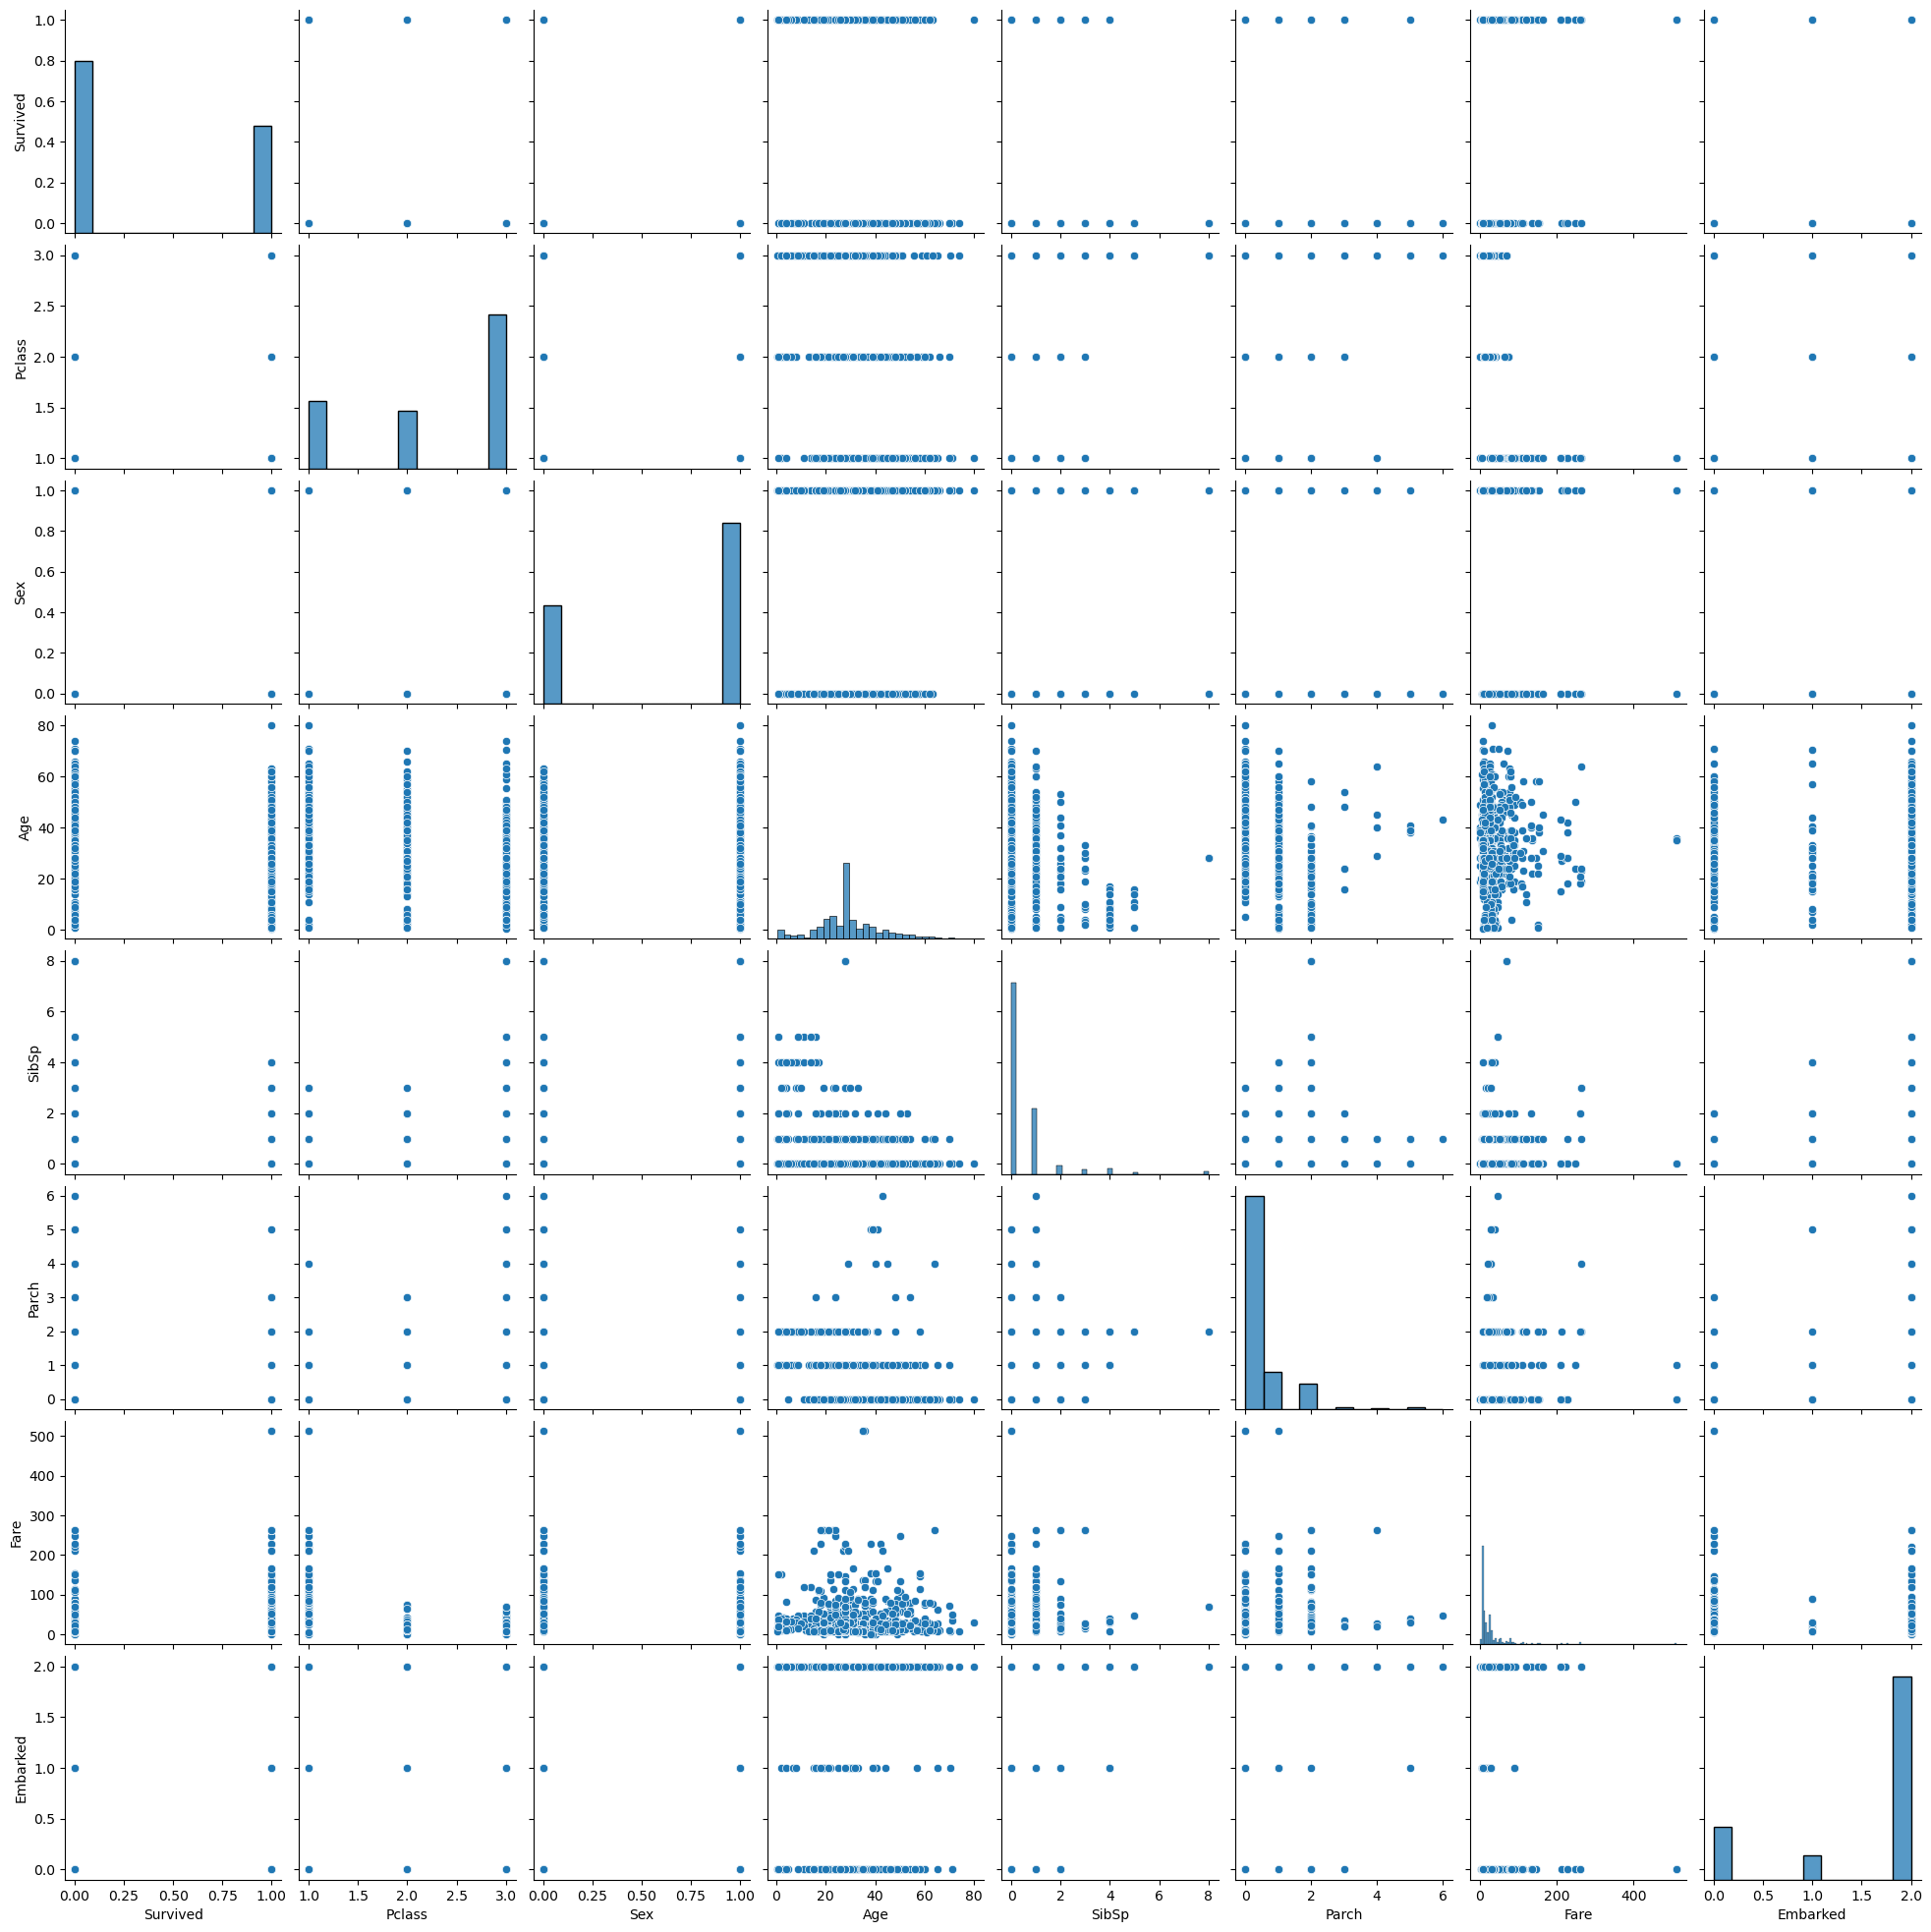

In [14]:
sns.pairplot(df) ## pairplot

In [15]:
df.corr().round(2) ## correlation

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
Survived,1.00,-0.34,-0.54,-0.06,-0.04,0.08,0.26,-0.17
Pclass,-0.34,1.00,0.13,-0.34,0.08,0.02,-0.55,0.16
Sex,-0.54,0.13,1.00,0.08,-0.11,-0.25,-0.18,0.11
Age,-0.06,-0.34,0.08,1.00,-0.23,-0.17,0.10,-0.02
SibSp,-0.04,0.08,-0.11,-0.23,1.00,0.41,0.16,0.07
Parch,0.08,0.02,-0.25,-0.17,0.41,1.00,0.22,0.04
Fare,0.26,-0.55,-0.18,0.10,0.16,0.22,1.00,-0.22
Embarked,-0.17,0.16,0.11,-0.02,0.07,0.04,-0.22,1.00


<Axes: >

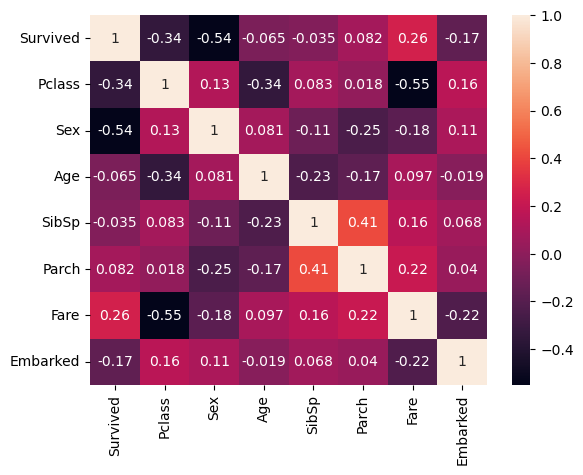

In [16]:
sns.heatmap(df.corr(), annot=True) ## heatmap

## we see that survival is most strongly correlated with sex and class, and then fare

In [17]:
df.groupby('Survived').agg({
    'Pclass': 'median',
    'Sex': 'median',
    'Age': 'median',
    'SibSp': 'median',
    'Parch': 'median',
    'Fare': 'median',
    'Embarked': 'median'}).round(2) ## we see that those who survived were of a higher class, were female, and had higher fare

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
Survived,,,,,,,
0,3.0,1.0,28.0,0.0,0.0,10.5,2.0
1,2.0,0.0,28.0,0.0,0.0,26.0,2.0


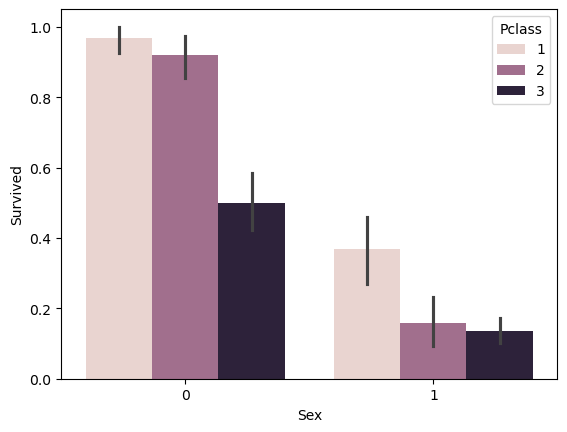

In [18]:
sns.barplot(x="Sex", y="Survived", hue="Pclass", data=df)
plt.show() ## relationship between sex, class, and survival percentage

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
X = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]
y = df['Survived']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42) ## stratified random sampling to deal with class imbalance

In [22]:
from sklearn.preprocessing import StandardScaler

In [23]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) ## standardise X_train

In [24]:
X_test_scaled = scaler.transform(X_test) ## standardise X_test using X_train

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [26]:
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Predictions and accuracy
y_pred_log = log_reg.predict(X_test_scaled)
accuracy_log = accuracy_score(y_test, y_pred_log)
print("Logistic Regression Accuracy:", accuracy_log) ## logistic regression

Logistic Regression Accuracy: 0.7713004484304933


In [27]:
from sklearn.metrics import confusion_matrix

In [28]:
confusion_matrix(y_test, y_pred_log) ## logistic regression confusion matrix

array([[114,  23],
       [ 28,  58]], dtype=int64)

In [29]:
from sklearn.tree import DecisionTreeClassifier

In [30]:
dec_tree = DecisionTreeClassifier(random_state=42)
dec_tree.fit(X_train_scaled, y_train)

# Predictions and accuracy
y_pred_dec_tree = dec_tree.predict(X_test_scaled)
accuracy_dec_tree = accuracy_score(y_test, y_pred_dec_tree)
print("Decision Tree Accuracy:", accuracy_dec_tree) ## decision tree

Decision Tree Accuracy: 0.7309417040358744


In [31]:
confusion_matrix(y_test, y_pred_dec_tree) ## decision tree confusion matrix

array([[108,  29],
       [ 31,  55]], dtype=int64)

In [32]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

In [33]:
n = 10
param_grid = {'n_neighbors': np.arange(n)}
grid = GridSearchCV(KNeighborsClassifier(), param_grid) ## grid search for best knn # of neighbours

In [34]:
grid.fit(X_train_scaled, y_train)

C:\Users\llin\AppData\Local\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:547: FitFailedWarning: 
5 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\llin\AppData\Local\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 895, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\llin\AppData\Local\anaconda3\Lib\site-packages\sklearn\base.py", line 1467, in wrapper
    estimator._validate_params()
  File "C:\Users\llin\AppData\Local\anaconda3\Lib\site-packages\sklearn\base.py", line 666, in _validate_params
    validate_parameter_constraints(
 

GridSearchCV(estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])})

In [35]:
knn = grid.best_estimator_
y_pred_knn = knn.fit(X_train_scaled, y_train).predict(X_test_scaled)

In [36]:
# Predictions and accuracy
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print("KNN Accuracy:", accuracy_knn) ## knn is most accurate in predicting survival

KNN Accuracy: 0.7802690582959642


In [37]:
confusion_matrix(y_test, y_pred_knn) ## knn confusion matrix

array([[119,  18],
       [ 31,  55]], dtype=int64)